## Random Forest Classifier
>1. Train Random Forest on TreeLSM embeddings 
>2. Train on both Clinical Data concatenated with TreeLSM embeddings
>3. Compare Feature Importance of both

Test Accuracy: 0.4412, AUC: 0.4464
[[11 20]
 [18 19]]
              precision    recall  f1-score   support

           0       0.38      0.35      0.37        31
           1       0.49      0.51      0.50        37

    accuracy                           0.44        68
   macro avg       0.43      0.43      0.43        68
weighted avg       0.44      0.44      0.44        68



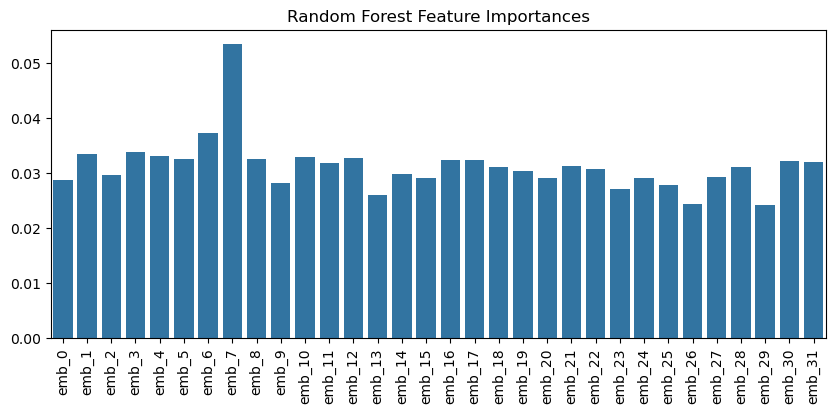

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load embeddings + labels
emb = pd.read_csv("patient_embeddings_with_labels.csv")
tx = pd.read_csv("data/tracerX.csv")
tx.columns = tx.columns.str.strip()

tx_keep = tx[['cruk_id', 'dfs_time', 'cens_dfs']].copy()
df_features = emb.merge(tx_keep, on='cruk_id', how='inner')
df_features = df_features.dropna(subset=['dfs_time', 'cens_dfs'])
df_features = df_features[df_features['dfs_time'] > 0]

# Feature matrix and labels
X = df_features[[str(i) for i in range(32)]].values
y = df_features['shorter_dfs_balanced'].values  # or whichever target

# Train Random Forest Classifier
# Features and labels
#X = df_features[[str(i) for i in range(32)]].values  # embedding columns
#y = df_features['cens_dfs'].values  # binary event: 1=event, 0=censored

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
importances = rf.feature_importances_
plt.figure(figsize=(10,4))
sns.barplot(x=[f"emb_{i}" for i in range(32)], y=importances)
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importances")
plt.show()

Columns in tx: ['cruk_id', 'tumour_id_muttable_cruk', 'tumour_id_per_patient', 'age', 'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears', 'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM', 'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient', 'PL_per_patient', 'margin_status_per_patient', 'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1', 'histology_lesion1_merged', 'lesion1_sampled', 'histology_lesion2', 'lesion2_sampled', 'histology_multi_full', 'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype', 'adjuvant_treatment_YN', 'adjuvant_treatment_given', 'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned', 'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use', 'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'cens_os', 'os_time', 'cens_dfs', 'dfs_time', 'cens_dfs_any_event', 'dfs_time_any_event', 'cens_lung_event', 'lung_event_time', 'R

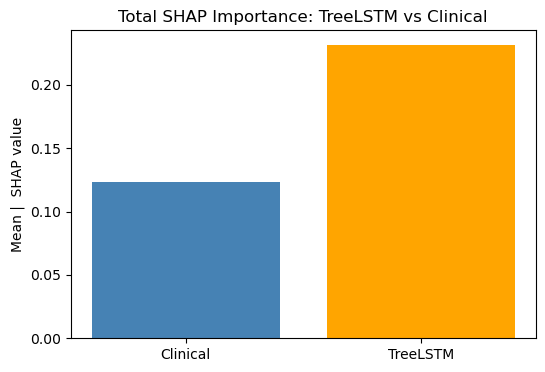

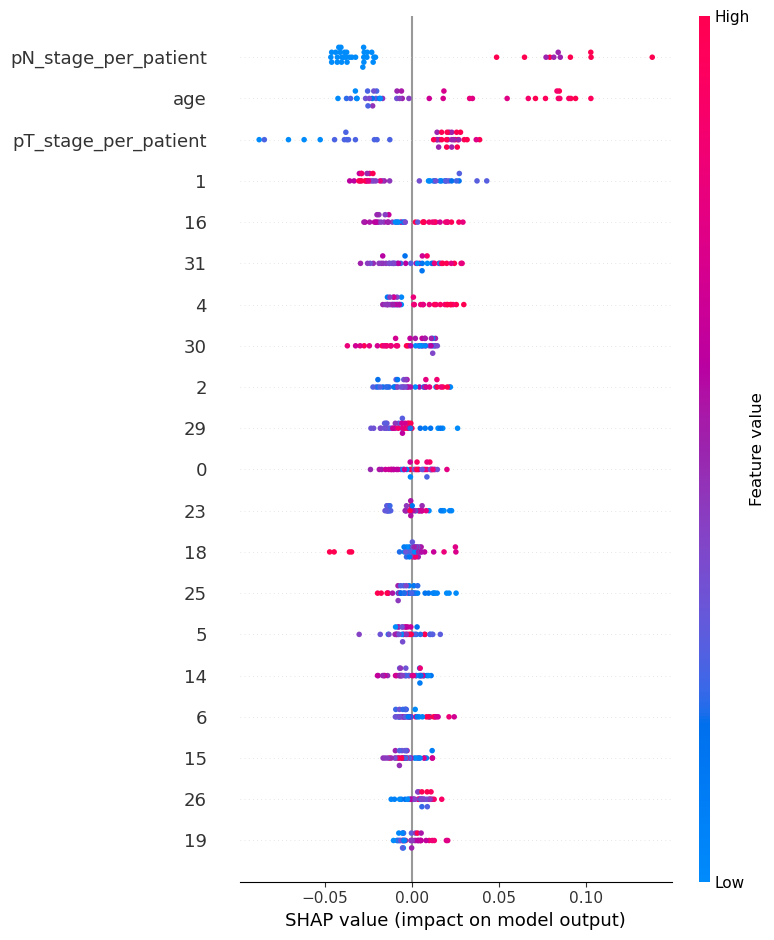

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

# Load embeddings and clinical data
emb = pd.read_csv("patient_embeddings_with_labels.csv")  # TreeLSTM embeddings
tx = pd.read_csv("data/tracerX.csv")
tx.columns = tx.columns.str.strip()
cleaned_tx_by_nan = pd.read_csv("data/20221109_TRACERx421_all_patient_df_Converted.csv")

# Drop column 'Unnamed: 0' if it exists
if 'Unnamed: 0' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.drop(columns=['Unnamed: 0'])
# Rename 'patient_id' to 'cruk_id' in cleaned_tx_by_nan
if 'patient_id' in cleaned_tx_by_nan.columns:
    cleaned_tx_by_nan = cleaned_tx_by_nan.rename(columns={'patient_id': 'cruk_id'})

print(f"Columns in tx: {tx.columns.tolist()}")
print(f"Size of tx: {tx.shape}")
print(f"Columns in all_patient_df: {cleaned_tx_by_nan.columns.tolist()}")
print(f"Size of all_patient_df: {cleaned_tx_by_nan.shape}")

# Convert numeric IDs to CRUK format (zero-padded 4 digits)
cleaned_tx_by_nan['cruk_id'] = cleaned_tx_by_nan['cruk_id'].astype(str).str.zfill(4)
cleaned_tx_by_nan['cruk_id'] = "CRUK" + cleaned_tx_by_nan['cruk_id']

# Let's use the relevant clinical features from cleaned_tx_by_nan
tx_keep = cleaned_tx_by_nan.copy()
# Print first few rows of 'cruk_id' in both dataframes for debugging
print("First few 'cruk_id' values in embeddings DataFrame (emb):")
print(emb['cruk_id'].head())
print(emb['cruk_id'].size)
print("First few 'cruk_id' values in clinical features DataFrame (tx_keep):")
print(tx_keep['cruk_id'].head())
print(tx_keep['cruk_id'].size)

# Ensure 'cruk_id' exists in both DataFrames
if 'cruk_id' not in emb.columns:
    raise KeyError("'cruk_id' column is missing in the embeddings DataFrame (emb). Please check the input file.")
if 'cruk_id' not in tx_keep.columns:
    raise KeyError("'cruk_id' column is missing in the clinical features DataFrame (tx_keep). Please check the input file.")

# Merge embeddings with clinical features
df_features = emb.merge(tx_keep, on='cruk_id', how='inner')

# Ensure 'dfs_time' and 'cens_dfs' exist before dropping NaN values
if 'dfs_time' not in df_features.columns or 'cens_dfs' not in df_features.columns:
    raise KeyError("'dfs_time' or 'cens_dfs' column is missing in the merged DataFrame (df_features). Please check the input files.")

df_features = df_features.dropna(subset=['dfs_time', 'cens_dfs'])

# Define feature groups
tree_cols = [str(i) for i in range(32)]     # TreeLSTM embedding columns
clinical_cols = ['age', 'pT_stage_per_patient', 'pN_stage_per_patient', 'sex']  # example clinical features

# Drop rows with NaN values in clinical columns after conversion
df_features = df_features.dropna(subset=clinical_cols)

X = df_features[tree_cols + clinical_cols]
y = df_features['cens_dfs']

# Check if the dataset has enough samples for splitting
if len(X) < 2:
    raise ValueError("Not enough samples in the dataset after filtering. Please check the filtering criteria.")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# SHAP analysis
explainer = shap.TreeExplainer(rf)
shap_exp = explainer(X_test)  # Explanation object

# Access SHAP values
shap_values_all = shap_exp.values  # shape: (n_samples, n_features, n_classes)

print("SHAP values shape:", shap_values_all.shape)
print("X_test shape:", X_test.shape)

# Select class 1 (positive class)
shap_values = shap_values_all[:, :, 1]  # now (n_samples, n_features)
print("Fixed SHAP values shape:", shap_values.shape)

# Compute per-feature importance
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Plot group-level comparison
plt.figure(figsize=(6,4))
group_importance = importance_df.groupby("group")["importance"].sum().reset_index()
plt.bar(group_importance["group"], group_importance["importance"], color=["steelblue","orange"])
plt.title("Total SHAP Importance: TreeLSTM vs Clinical")
plt.ylabel("Mean |  SHAP value")
plt.show()

# Detailed per-feature summary
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

Explaining patient at index 0, true label = 1
Patient 0, true label = 1


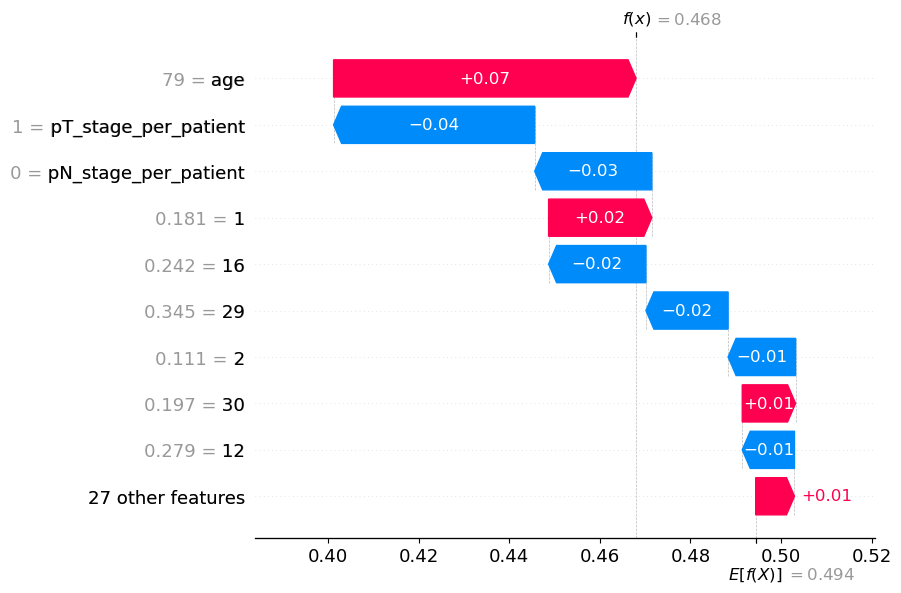

Patient 1, true label = 1


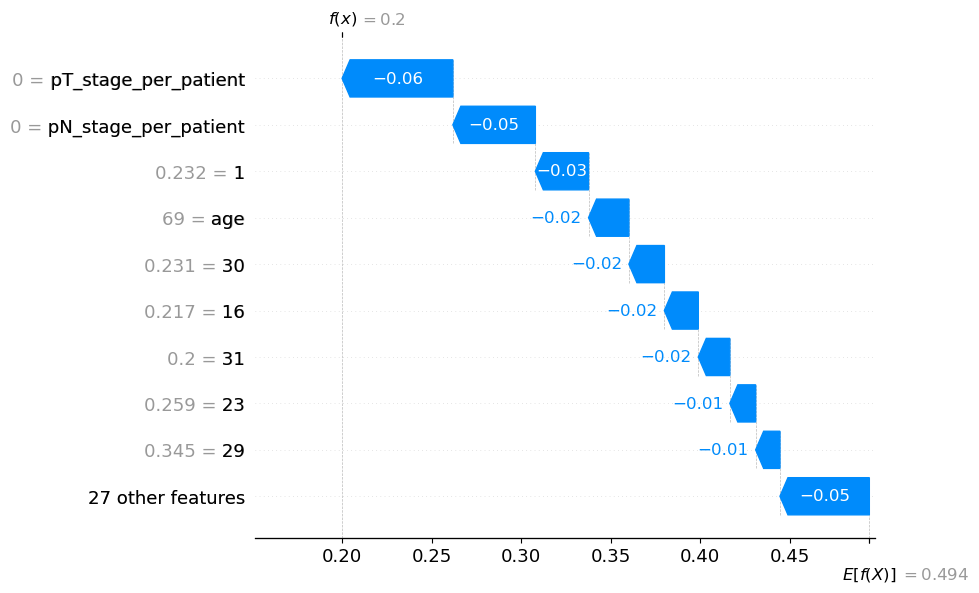

Patient 2, true label = 1


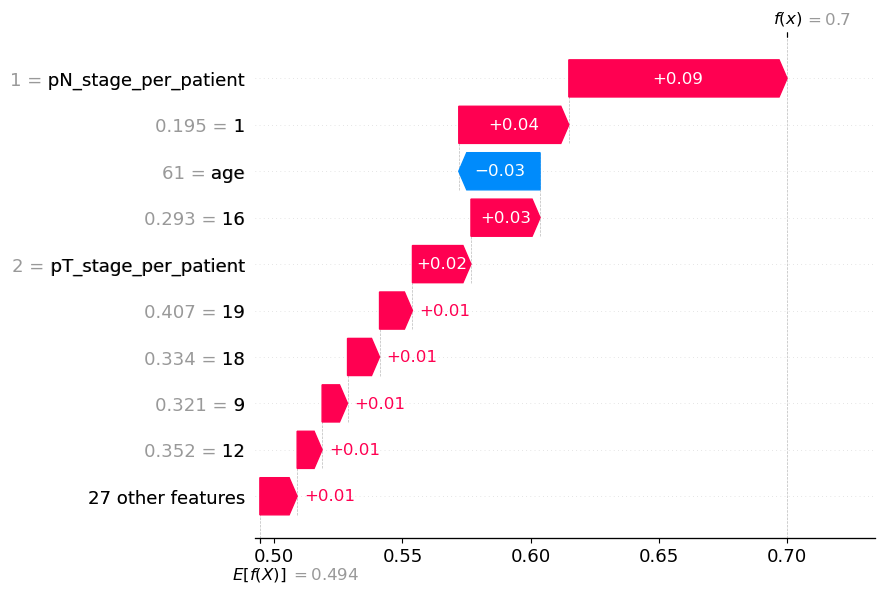

In [116]:
# Pick one example patient from the test set
i = 0  # index of the patient in X_test
sample = X_test.iloc[i]
# For binary classifiers, explainer.expected_value is a list of two base values
base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]  # baseline for class 1

print(f"Explaining patient at index {i}, true label = {y_test.iloc[i]}")


# Plot waterfall for first 3 patients
for idx in range(3):
    sample = X_test.iloc[idx]
    true_label = y_test.iloc[idx]

    # For binary classifiers, pick the base value for class 1
    base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]

    print(f"Patient {idx}, true label = {true_label}")

    shap_exp_patient = shap.Explanation(
        values=shap_values[idx],     # SHAP values for this patient (all features)
        base_values=base_val,       # baseline for class 1
        data=sample.values,
        feature_names=X_test.columns
    )

    # Use the modern waterfall plot
    shap.plots.waterfall(shap_exp_patient)


Using clinical features: ['shorter_dfs_balanced', 'age', 'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears', 'smoking_status_merged', 'is.family.lung', 'ECOG_PS', 'pathologyTNM', 'pT_stage_per_patient', 'pN_stage_per_patient', 'LVI_per_patient', 'size_pathology_per_patient', 'Surgery_type', 'histology_lesion1', 'lesion1_sampled', 'histology_lesion2', 'lesion2_sampled', 'histology_multi_full', 'histology_multi_full_genomically.confirmed', 'LUAD_pred_subtype', 'adjuvant_treatment_YN', 'adjuvant_treatment_given', 'num_cycle_na.added', 'CHMPlatDgName_cleaned', 'CHMOthDgName_cleaned', 'AdjRadStartTime_manual', 'AdjRadEndTime_manual', 'Recurrence_time_use', 'newPrim_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'cens_os', 'os_time', 'cens_dfs_any_event', 'dfs_time_any_event', 'cens_lung_event', 'lung_event_time', 'Relapse_cat', 'Relapse_cat_new', 'tx100']


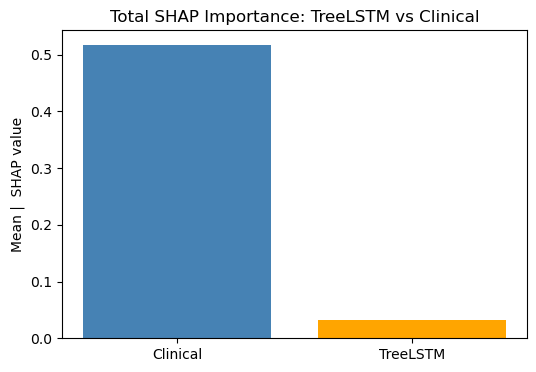

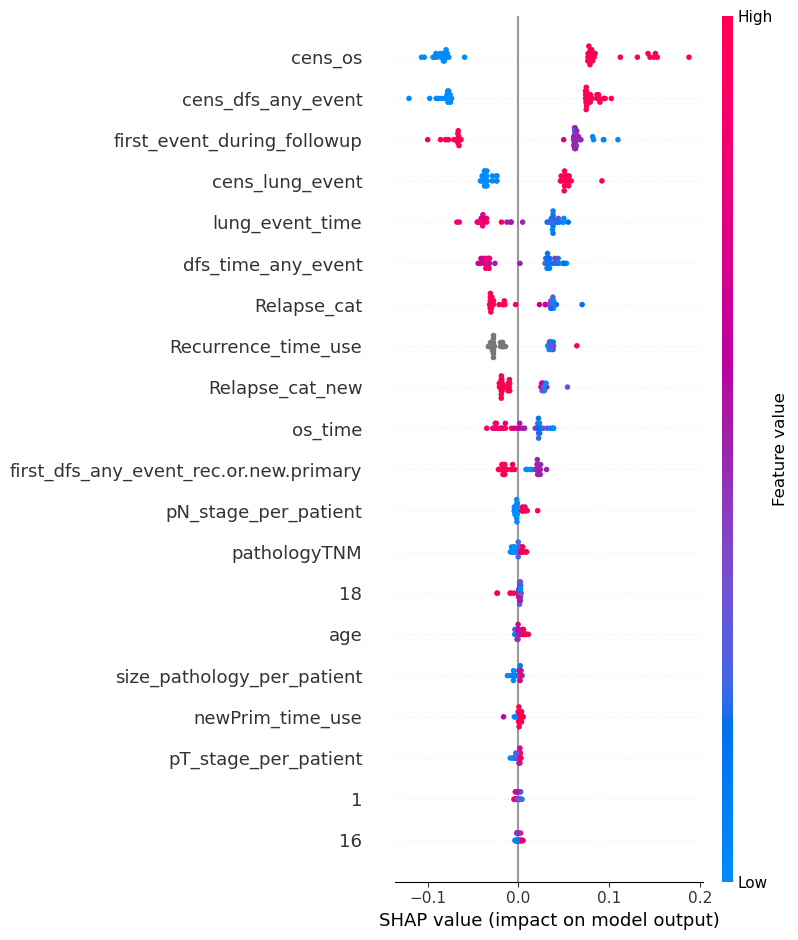

In [120]:
# Identify TreeLSTM columns (0 to 31)
tree_cols = [str(i) for i in range(32)]

# Automatically select all clinical columns
clinical_cols = [c for c in df_features.columns if c not in tree_cols + ['cruk_id', 'dfs_time', 'cens_dfs']]

print("Using clinical features:", clinical_cols)

# Prepare feature matrix
X = df_features[tree_cols + clinical_cols]
y = df_features['cens_dfs']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# --- SHAP analysis ---
explainer = shap.TreeExplainer(rf)
shap_exp = explainer(X_test)  # returns Explanation object

# Extract SHAP values
shap_values = shap_exp.values  # shape: (n_samples, n_features) or (n_samples, n_features, n_classes)

# Handle binary/multi-class
if shap_values.ndim == 3:  # multi-class
    # For binary classification, pick the positive class automatically
    if shap_values.shape[2] == 2:
        shap_values = shap_values[:, :, 1]  # positive class
    else:
        # For >2 classes, you could either pick a class or sum/average across classes
        shap_values = shap_values.mean(axis=2)  # average SHAP across classes

# Per-feature importance
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})
importance_df["group"] = importance_df["feature"].apply(
    lambda f: "TreeLSTM" if f in tree_cols else "Clinical"
)

# Group-level plot
plt.figure(figsize=(6,4))
group_importance = importance_df.groupby("group")["importance"].sum().reset_index()
plt.bar(group_importance["group"], group_importance["importance"], color=["steelblue","orange"])
plt.title("Total SHAP Importance: TreeLSTM vs Clinical")
plt.ylabel("Mean |  SHAP value")
plt.show()

# Detailed per-feature SHAP summary
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

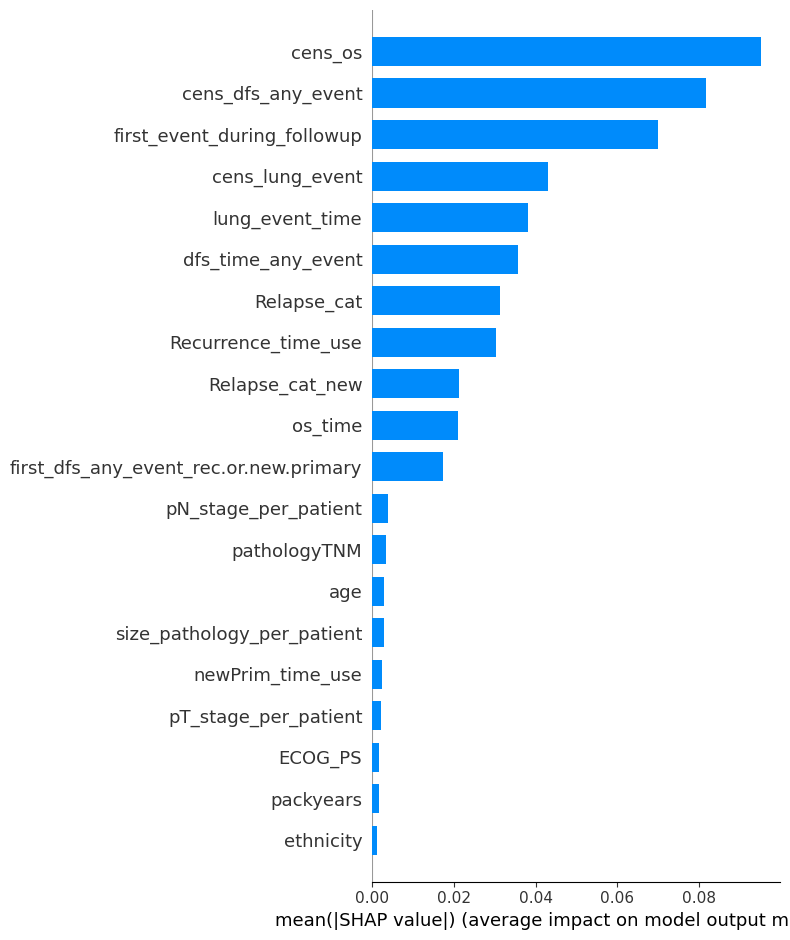

In [ ]:
# Clinical features only
X_test_clinical = X_test[clinical_cols]
shap_values_clinical = shap_values[:, [X_test.columns.get_loc(f) for f in clinical_cols]]

# Summary plot for clinical features
shap.summary_plot(
    shap_values_clinical, 
    X_test_clinical, 
    feature_names=clinical_cols,
    plot_type="bar"
)

### Most Important Clinical Features


In [74]:
print("SHAP analysis completed successfully.")
# Print the top features by importance
top_features = importance_df.sort_values(by="importance", ascending=False).head(10)
print("Top features by SHAP importance:")
print(top_features)


SHAP analysis completed successfully.
Top features by SHAP importance:
                        feature  importance     group
66                      cens_os    0.095050  Clinical
68           cens_dfs_any_event    0.081789  Clinical
65  first_event_during_followup    0.069880  Clinical
70              cens_lung_event    0.043056  Clinical
71              lung_event_time    0.038122  Clinical
69           dfs_time_any_event    0.035696  Clinical
72                  Relapse_cat    0.031286  Clinical
62          Recurrence_time_use    0.030381  Clinical
73              Relapse_cat_new    0.021170  Clinical
67                      os_time    0.020986  Clinical


Patient 0, true label = 1 (clinical features only)


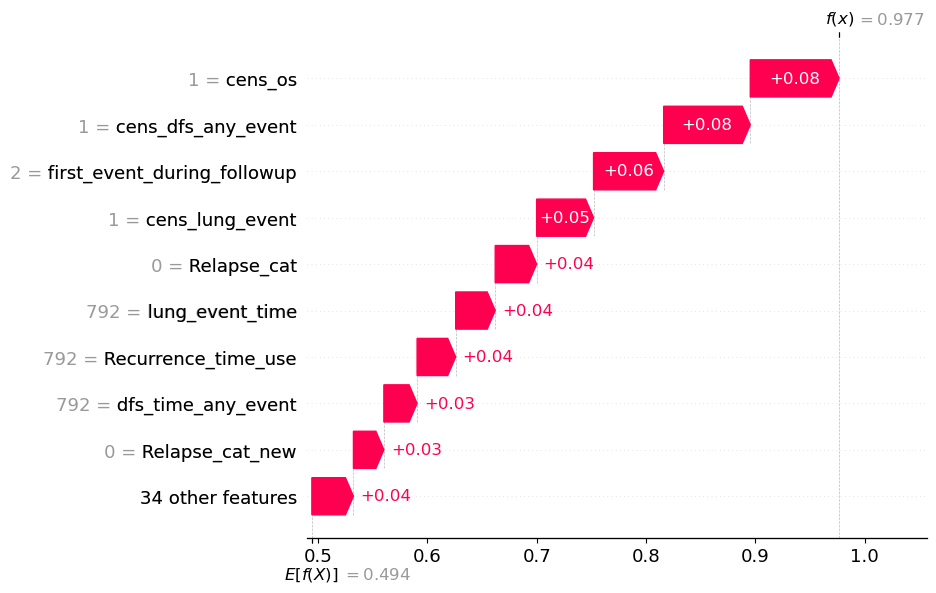

Patient 1, true label = 1 (clinical features only)


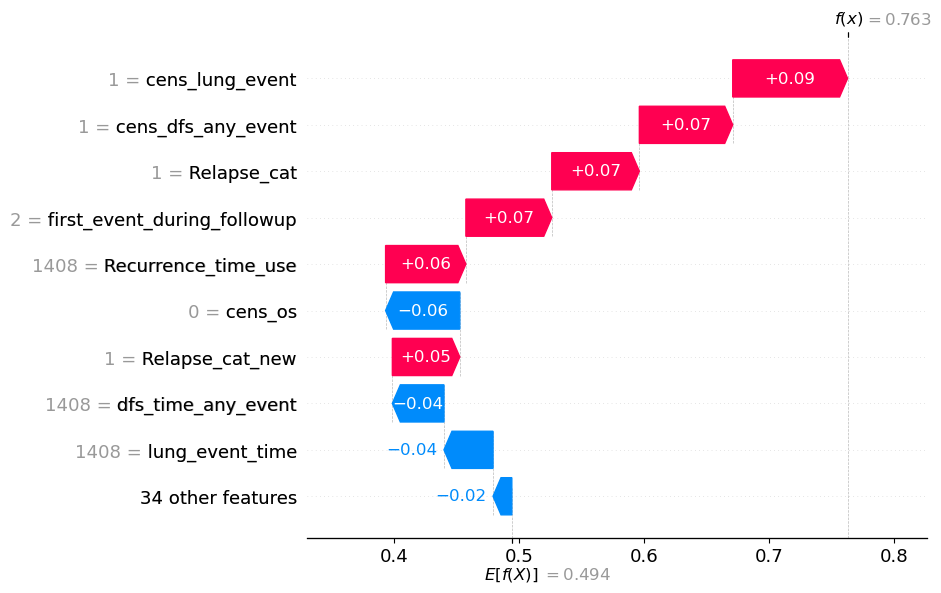

Patient 2, true label = 1 (clinical features only)


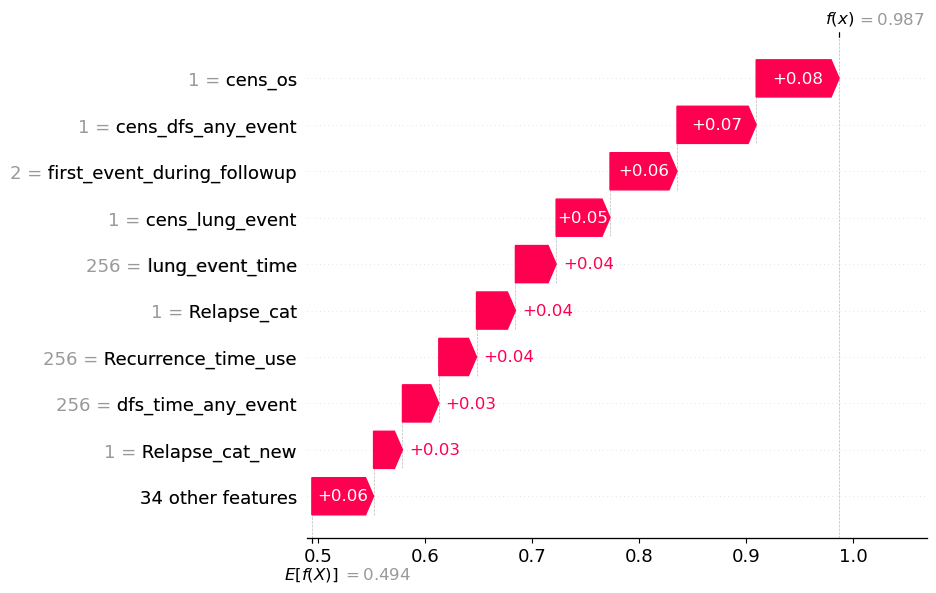

In [119]:
# Get all clinical columns automatically (exclude embedding columns)
clinical_cols = [c for c in X_test.columns if c not in tree_cols]

# Extract SHAP values for clinical features
clinical_indices = [X_test.columns.get_loc(f) for f in clinical_cols]

# Plot waterfall for first 3 patients
for idx in range(3):
    sample = X_test[clinical_cols].iloc[idx]
    true_label = y_test.iloc[idx]

    # Extract SHAP values only for clinical features
    values_clinical = shap_values[idx][clinical_indices]

    # For binary classifier: pick base value for class 1
    base_val = explainer.expected_value if isinstance(explainer.expected_value, float) else explainer.expected_value[1]

    print(f"Patient {idx}, true label = {true_label} (clinical features only)")

    shap_exp_patient = shap.Explanation(
        values=values_clinical,
        base_values=base_val,
        data=sample.values,
        feature_names=clinical_cols
    )

    shap.plots.waterfall(shap_exp_patient)
